# knn yex8wb


In [ ]:
# import libraries lol
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

In [32]:
# define csv as datagrame, preview data
df = pd.read_csv("wages_hw.csv")
df.head()

,Unnamed: 0,Rating,Size,Sector,avg_salary,job_state
0,1,3.8,501 to 1000 employees,Aerospace & Defense,72.0,NM
1,2,3.4,10000+ employees,Health Care,87.5,MD
2,3,4.8,501 to 1000 employees,Business Services,85.0,FL
3,4,3.8,1001 to 5000 employees,"Oil, Gas, Energy & Utilities",76.5,WA
4,5,2.9,51 to 200 employees,Business Services,114.5,NY


<Axes: xlabel='Rating', ylabel='avg_salary'>

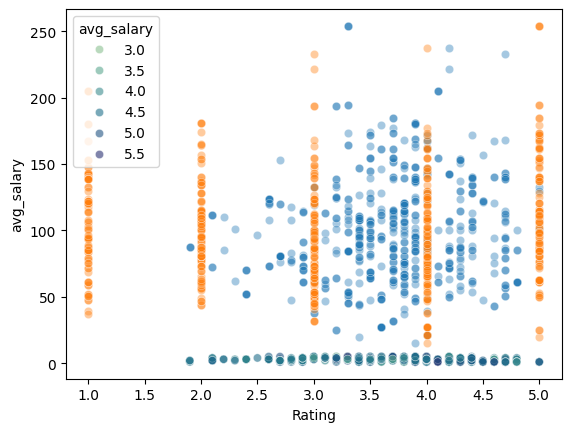

In [33]:
# make company size numeric to make it plottable
size_map = {
    '51 to 200 employees': 1,
    '201 to 500 employees': 2,
    '501 to 1000 employees': 3,
    '1001 to 5000 employees': 4,
    '10000+ employees': 5
}

# new column 
df['Size_num'] = df['Size'].map(size_map)

# drop the missing val
df = df[['avg_salary', 'Rating', 'Size_num']].dropna()

#on my eda
sns.scatterplot(x=df['Rating'], y=df['avg_salary'], alpha=0.4)
sns.scatterplot(x=df['Size_num'], y=df['avg_salary'], alpha=0.4)
sns.scatterplot(
    x=df['Rating'],
    y=df['Size_num'],
    hue=np.log(df['avg_salary']),
    palette='crest',
    alpha=0.6
)


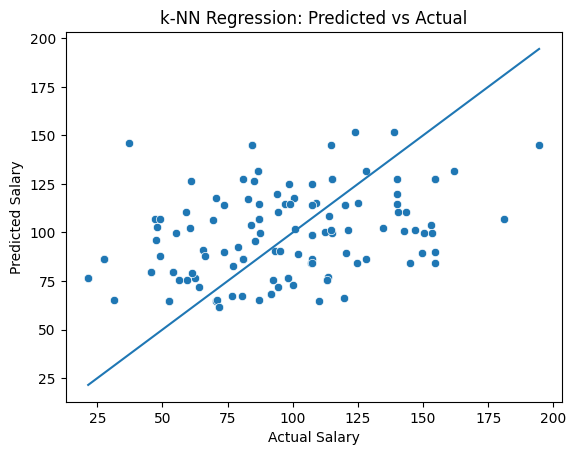

In [34]:
#min max normailization
def minmax(x):
    return (x - x.min()) / (x.max() - x.min())

# y = outcome predictor 
y = df['avg_salary']

# predictor col and store as x 
ctrl_list = ['Rating', 'Size_num']
x = df.loc[:, ctrl_list]

# col wise min max scaling + 80/20 split type 
u = x.apply(minmax)
u_train, u_test, y_train, y_test = train_test_split(
    u, y, test_size=0.2, random_state=10
)
k = 5

# here is the model

model = KNeighborsRegressor(n_neighbors=k)
model = model.fit(u_train, y_train)

# prediction and plot
y_hat = model.predict(u_test)
sns.scatterplot(x=y_test, y=y_hat)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("k-NN Regression: Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],)
plt.show()



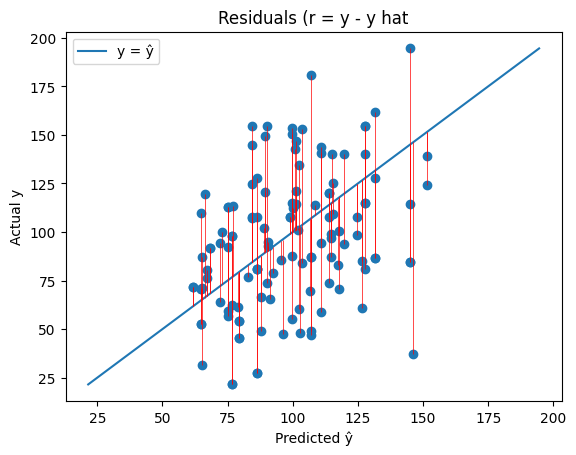

In [22]:
y_test_np = np.asarray(y_test)
y_hat_np = np.asarray(y_hat)

lo = np.min([y_test_np.min(), y_hat_np.min()])
hi = np.max([y_test_np.max(), y_hat_np.max()])

plt.plot([lo, hi], [lo, hi], label='y = ŷ')
plt.scatter(y_hat_np, y_test_np)

for a, b in zip(y_hat_np, y_test_np):
    plt.vlines(a, a, b, color='red', linewidth=0.5)

plt.xlabel("Predicted ŷ")
plt.ylabel("Actual y")
plt.title("Residuals (r = y - y hat")
plt.legend()
plt.show()




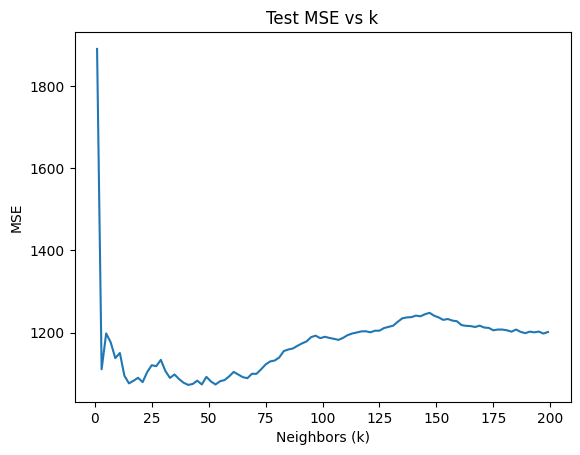

In [27]:
def mse(y_test, y_hat):
    return np.sum((y_test - y_hat) ** 2) / len(y_test)
mse(y_test_np, y_hat_np)

k_grid = [(2*k + 1) for k in range(100)]
mses = []

for k in k_grid:
    model = KNeighborsRegressor(n_neighbors=k)
    model = model.fit(u_train, y_train)
    y_hat = model.predict(u_test)
    mses.append(mse(y_test, y_hat))

sns.lineplot(x=k_grid, y=mses)
plt.xlabel("Neighbors (k)")
plt.ylabel("MSE")
plt.title("Test MSE vs k")
plt.show()


# conclusion

reasonable predictions but to many large errors at the extremes